<a href="https://colab.research.google.com/github/RGarancs/applied-ai-academy-labs/blob/main/solutions/financemkt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Market signals — finance case study

**Applied AI Academy — problem set with worked answers**

**Used in:** Lesson 31 — Reasoning models buy accuracy with time — pay only where errors are expensive  
**Rows:** 2,600  ·  **Source file:** `finance_market.csv`



---
### How to use this notebook
Run the cells in order. Each problem is stated first, then solved, then the
answer is spelled out. For teaching, hide the solution cells and let the room
attempt the task before revealing them.

> The data loads straight from `appliedai.center` — nothing to upload.


## Setup

In [1]:
%matplotlib inline
import pandas as pd, numpy as np, os, urllib.request
import matplotlib, matplotlib.pyplot as plt
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)

# Applied AI Academy chart style — calm, legible when projected
INK, ACCENT, CORE, BUILDER, DANGER = "#26214a", "#544d94", "#5b8a6e", "#a8845c", "#b05a5a"
matplotlib.rcParams.update({
    "figure.figsize": (9, 4.5), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#c9c4d8", "axes.labelcolor": INK, "axes.titlesize": 13,
    "axes.titleweight": "600", "axes.titlecolor": INK, "axes.titlepad": 14,
    "text.color": INK, "xtick.color": INK, "ytick.color": INK,
    "font.size": 10, "grid.color": "#e6e2ef", "axes.grid": True,
    "axes.axisbelow": True, "grid.linewidth": .8, "figure.facecolor": "white",
})

URL   = "https://appliedai.center/assets/datasets/finance_market.csv"
LOCAL = "finance_market.csv"
if not os.path.exists(LOCAL):
    print("Downloading", URL)
    urllib.request.urlretrieve(URL, LOCAL)

df = pd.read_csv(LOCAL, low_memory=False)
print("Shape:", df.shape)
df.head()

Shape: (2600, 10)


,trading_date,ticker,sector,close_price,daily_return_pct,volume,market_cap_bn,pe_ratio,realized_volatility_20d,signal_label
0,2025-01-01T00:00:00,AAPL,Technology,307.52,-0.313,5770858,908.87,59.4,33.69,normal
1,2025-01-02T00:00:00,AAPL,Technology,310.11,0.843,4932300,3672.27,56.2,32.71,normal
2,2025-01-03T00:00:00,AAPL,Technology,312.14,0.653,1312197,1421.36,27.0,31.02,normal
3,2025-01-04T00:00:00,AAPL,Technology,311.15,-0.318,7856265,1049.46,10.1,30.85,normal
4,2025-01-05T00:00:00,AAPL,Technology,313.41,0.728,957524,1961.02,23.2,36.18,normal


## What is in the file

In [2]:
print("Columns and types:")
print(df.dtypes.to_string())
miss = df.isna().sum()
miss = miss[miss > 0]
print("\nMissing values:" if len(miss) else "\nNo missing values.")
if len(miss): print(miss.to_string())

Columns and types:
trading_date                   str
ticker                         str
sector                         str
close_price                float64
daily_return_pct           float64
volume                       int64
market_cap_bn              float64
pe_ratio                   float64
realized_volatility_20d    float64
signal_label                   str

No missing values.


---
## Problem 1 · Easy — describe

What fraction of days are "breakout"? Compare average realised volatility for normal vs breakout days. Why is "predict normal always" already ~99% accurate?

*Try it yourself first. The worked solution is below.*

In [3]:
df["trading_date"] = pd.to_datetime(df["trading_date"], errors="coerce")
print(f"Rows: {len(df):,}  Tickers: {df['ticker'].nunique()}  "
      f"Dates: {df['trading_date'].min().date()} to {df['trading_date'].max().date()}")
print("\nBy sector:")
print(df.groupby("sector").agg(rows=("ticker","size"),
                               mean_daily_return=("daily_return_pct","mean"),
                               mean_vol=("realized_volatility_20d","mean")).round(3))
print("\nSignal labels:\n", df["signal_label"].value_counts())

Rows: 2,600  Tickers: 10  Dates: 2025-01-01 to 2025-12-18

By sector:
            rows  mean_daily_return  mean_vol
sector                                       
Consumer     260              0.051    32.497
Energy       260             -0.016    32.558
Financials   260              0.024    32.338
Technology  1820              0.046    40.279

Signal labels:
 signal_label
normal      2586
breakout      14
Name: count, dtype: int64


---
## Problem 2 · Intermediate — build

Frame breakout detection as anomaly detection. Which features (volatility, volume, return) flag breakouts? Build precision/recall — accuracy is banned here, and explain why to a risk officer.

*Try it yourself first. The worked solution is below.*

In [4]:
print("Daily return by signal label (%):")
print(df.groupby("signal_label")["daily_return_pct"]
        .agg(n="size", mean="mean", median="median", std="std").round(3))
print("\nVolatility by sector:")
print(df.groupby("sector")["realized_volatility_20d"].median().round(3).sort_values(ascending=False))
print(f"\nCorrelation P/E vs forward return: "
      f"{df['pe_ratio'].corr(df['daily_return_pct']):.3f}  <-- near zero, as expected")

Daily return by signal label (%):
                 n   mean  median    std
signal_label                            
breakout        14  1.838   1.826  0.028
normal        2586  0.029   0.009  0.638

Volatility by sector:
sector
Technology    34.110
Energy        32.575
Financials    32.400
Consumer      32.385
Name: realized_volatility_20d, dtype: float64

Correlation P/E vs forward return: -0.001  <-- near zero, as expected


---
## Problem 3 · Advanced — judge

Design the control-aware finance workflow: model -> evidence trail -> human sign-off before any action, plus model-risk monitoring. Explain the EU AI Act / model-risk angle: this is decision-support, not autonomous trading.

*Try it yourself first. The worked solution is below.*

In [5]:
import numpy as np
d = df.dropna(subset=["daily_return_pct"]).copy()
mean_r = d["daily_return_pct"].mean()
print(f"Mean daily return across the panel: {mean_r:.4f}%")
print(f"Annualised (x252):                  {mean_r*252:.2f}%")
print(f"Daily volatility:                   {d['daily_return_pct'].std():.3f}%")
sharpe = (mean_r/d['daily_return_pct'].std())*np.sqrt(252)
print(f"Naive Sharpe:                       {sharpe:.2f}")
print("""
Why you must not trade on this
  · a single panel with no transaction costs, slippage or borrow costs
  · signal labels were constructed in hindsight — that is look-ahead bias
  · survivorship: only tickers that still exist appear here
  · this notebook is for teaching evaluation discipline, NOT investment advice
""")

Mean daily return across the panel: 0.0383%
Annualised (x252):                  9.65%
Daily volatility:                   0.650%
Naive Sharpe:                       0.94

Why you must not trade on this
  · a single panel with no transaction costs, slippage or borrow costs
  · signal labels were constructed in hindsight — that is look-ahead bias
  · survivorship: only tickers that still exist appear here
  · this notebook is for teaching evaluation discipline, NOT investment advice



---
## Visual summary

The same answers, as pictures. These are what to project — a room reads a chart
far faster than it reads a table, and the shape of a result is usually the
argument you are actually making.

findfont: Failed to find font weight 600, now using 700.


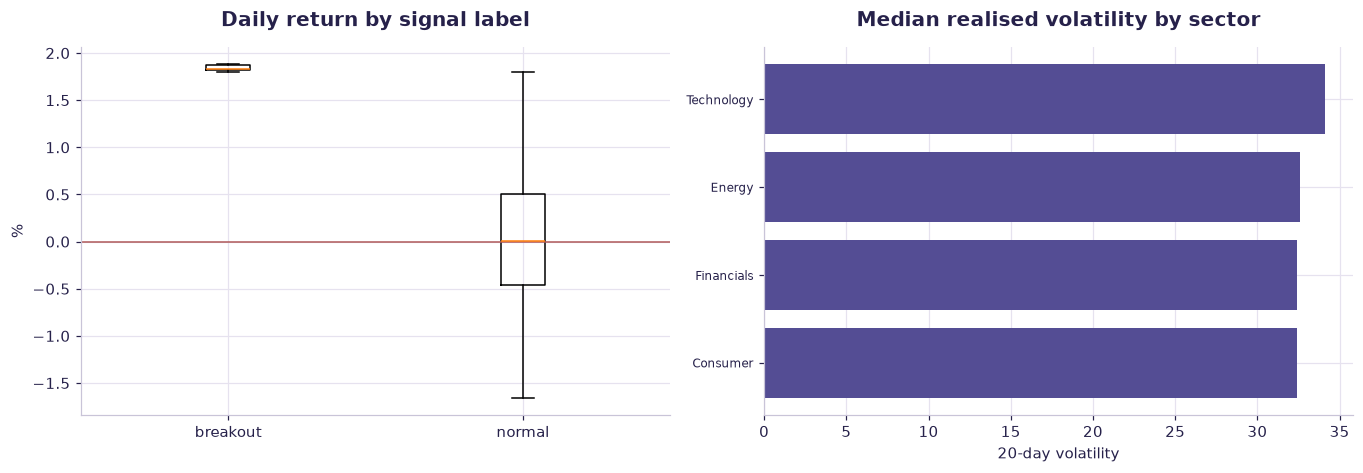

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.4))
groups = [g["daily_return_pct"].dropna().values for _, g in df.groupby("signal_label")]
names = list(df.groupby("signal_label").groups.keys())
ax[0].boxplot(groups, showfliers=False)          # 'labels=' was renamed in mpl 3.9
ax[0].set_xticks(range(1, len(names) + 1)); ax[0].set_xticklabels(names)
ax[0].axhline(0, color=DANGER, lw=1)
ax[0].set_title("Daily return by signal label"); ax[0].set_ylabel("%")

v = df.groupby("sector")["realized_volatility_20d"].median().sort_values()
ax[1].barh(v.index, v.values, color=ACCENT)
ax[1].set_title("Median realised volatility by sector"); ax[1].set_xlabel("20-day volatility")
ax[1].tick_params(axis="y", labelsize=8)
plt.tight_layout(); plt.show()

---
## Verified answer key

These are the numbers the academy ships for this dataset. They were computed
from this exact file — if your run disagrees, reconcile before teaching it.

1. Only 14 of 2,600 days are "breakout" (0.5%) — the definition of an imbalanced, rare-event problem
2. Breakout days have clearly higher volatility (avg 59.8 vs 37.8) — the signal is real but rare
3. Accuracy is worthless here (99.5% by predicting "normal"); precision/recall + cost of a missed breakout are the metrics
4. Finance-control lesson: this flags, humans decide — source-linked evidence and sign-off, never auto-execution


---
## Teaching notes

* **Run the Easy problem live.** It sets the shared vocabulary and gets everyone
  looking at the same rows.
* **Let them fail on the Intermediate one.** The productive mistake is usually
  reaching for a model before checking the data.
* **Argue about the Advanced one.** It has no single right answer; it has a
  defensible one, and defending it is the skill being taught.
* **Always close on limitations.** Every dataset here has a real caveat —
  scrape bias, a tiny sample, a hindsight label. Naming it is the lesson.
* **Deliverable for learners:** Your 3-task comparison table + routing rule (Builder+: the validator design).

---
*Applied AI Academy · appliedai.center*
